<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-45-decision-trees-intuition-code?scriptVersionId=349803408" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background: linear-gradient(135deg, #0a1f0a 0%, #0d2e10 50%, #0a1a0f 100%); padding: 48px 40px; border-radius: 16px; margin-bottom: 8px; border: 1px solid #1a4a1a;">
  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 16px;">
    <span style="background: #16a34a; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 2px; padding: 4px 12px; border-radius: 20px; text-transform: uppercase;">ML Series · Episode 46</span>
    <span style="background: rgba(255,255,255,0.08); color: #86efac; font-size: 11px; font-weight: 600; padding: 4px 12px; border-radius: 20px;">Classification &amp; Regression</span>
  </div>
  <h1 style="color: #ffffff; font-size: 38px; font-weight: 800; margin: 0 0 12px 0; line-height: 1.2;">🌳 Decision Trees</h1>
  <p style="color: #86efac; font-size: 16px; margin: 0 0 6px 0; font-style: italic;">Entropy, Gini Impurity &amp; the CART Algorithm</p>
  <p style="color: #bbf7d0; font-size: 15px; margin: 0 0 28px 0; max-width: 680px; line-height: 1.6;">How a tree learns to ask the right questions — splitting data recursively to maximise purity, from information-theoretic foundations to RandomizedSearchCV tuning and 3D regression surfaces.</p>
  <div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #1a4a1a; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #16a34a; font-size: 20px; font-weight: 700;">Entropy &amp; Gini</div>
      <div style="color: #86efac; font-size: 12px; margin-top: 2px;">Two impurity criteria explained</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #1a4a1a; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #16a34a; font-size: 20px; font-weight: 700;">CART</div>
      <div style="color: #86efac; font-size: 12px; margin-top: 2px;">sklearn's underlying algorithm</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #1a4a1a; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #16a34a; font-size: 20px; font-weight: 700;">2 Datasets</div>
      <div style="color: #86efac; font-size: 12px; margin-top: 2px;">Iris (classification) &amp; California Housing (regression)</div>
    </div>
  </div>
</div>

<div style="background: #060e06; border-left: 5px solid #16a34a; border-radius: 0 10px 10px 0; padding: 20px 24px; margin: 24px 0; border: 1px solid #1a4a1a; border-left: 5px solid #16a34a;">
  <h2 style="color: #16a34a; font-size: 15px; font-weight: 700; text-transform: uppercase; letter-spacing: 1.5px; margin: 0 0 10px 0;">📋 Table of Contents</h2>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 4px;">
    <ol style="margin: 0; padding-left: 20px; color: #4ade80; line-height: 2.1; font-size: 14px;">
      <li><a href='#challenge' style='color: #4ade80; text-decoration: none;'>Quick Challenge — Which Split Wins?</a></li>
      <li><a href='#what' style='color: #4ade80; text-decoration: none;'>What is a Decision Tree?</a></li>
      <li><a href='#intuition' style='color: #4ade80; text-decoration: none;'>Geometric Intuition</a></li>
      <li><a href='#entropy' style='color: #4ade80; text-decoration: none;'>Entropy — Information Gain</a></li>
      <li><a href='#gini' style='color: #4ade80; text-decoration: none;'>Gini Impurity</a></li>
      <li><a href='#cart' style='color: #4ade80; text-decoration: none;'>The CART Algorithm</a></li>
    </ol>
    <ol start="7" style="margin: 0; padding-left: 20px; color: #4ade80; line-height: 2.1; font-size: 14px;">
      <li><a href='#pros' style='color: #4ade80; text-decoration: none;'>Advantages &amp; Disadvantages</a></li>
      <li><a href='#imports' style='color: #4ade80; text-decoration: none;'>Imports &amp; Setup</a></li>
      <li><a href='#regression' style='color: #4ade80; text-decoration: none;'>Decision Tree Regression — California Housing</a></li>
      <li><a href='#tuning' style='color: #4ade80; text-decoration: none;'>RandomizedSearchCV Hyperparameter Tuning</a></li>
      <li><a href='#importance' style='color: #4ade80; text-decoration: none;'>Feature Importance</a></li>
      <li><a href='#classification' style='color: #4ade80; text-decoration: none;'>Decision Tree Classification — Iris</a></li>
      <li><a href='#viz' style='color: #4ade80; text-decoration: none;'>Tree Visualisation &amp; Prediction Path</a></li>
      <li><a href='#3d' style='color: #4ade80; text-decoration: none;'>3D Regression Surface</a></li>
    </ol>
  </div>
</div>

<a id='challenge'></a>
<div style="background: #060e06; border: 2px solid #16a34a; border-radius: 14px; padding: 28px 32px; margin: 28px 0;">
  <div style="display: flex; align-items: center; gap: 10px; margin-bottom: 16px;">
    <span style="font-size: 22px;">🧠</span>
    <span style="color: #16a34a; font-weight: 800; font-size: 17px;">Quick Challenge — Which Split Would the Tree Choose?</span>
  </div>
  <div style="color: #bbf7d0; font-size: 14px; line-height: 1.7; margin-bottom: 20px;">
    A Decision Tree is considering two possible splits for a dataset of <strong style='color:#fff;'>100 samples</strong>:
  </div>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; margin-bottom: 20px;">
    <div style="background: rgba(255,255,255,0.04); border: 1px solid #1a4a1a; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #4ade80; font-weight: 700; font-size: 14px; margin-bottom: 10px;">Split A</div>
      <div style="color: #bbf7d0; font-size: 13px; line-height: 1.8;">
        Left leaf:  50 samples → <strong style='color:#fff;'>45 Class A</strong>, 5 Class B<br/>
        Right leaf: 50 samples → 10 Class A, <strong style='color:#fff;'>40 Class B</strong>
      </div>
      <div style="margin-top: 10px; color: #86efac; font-size: 12px;">→ Both leaves are fairly pure</div>
    </div>
    <div style="background: rgba(255,255,255,0.04); border: 1px solid #1a4a1a; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #4ade80; font-weight: 700; font-size: 14px; margin-bottom: 10px;">Split B</div>
      <div style="color: #bbf7d0; font-size: 13px; line-height: 1.8;">
        Left leaf:  50 samples → <strong style='color:#fff;'>30 Class A</strong>, 20 Class B<br/>
        Right leaf: 50 samples → <strong style='color:#fff;'>25 Class A</strong>, 25 Class B
      </div>
      <div style="margin-top: 10px; color: #86efac; font-size: 12px;">→ Both leaves are mixed / impure</div>
    </div>
  </div>
  <div style="background: rgba(22,163,74,0.12); border: 1px solid #16a34a; border-radius: 8px; padding: 14px 18px; margin-bottom: 16px;">
    <div style="color: #fff; font-weight: 700; margin-bottom: 6px;">🤔 Which split would a Decision Tree prefer?</div>
    <div style="display: flex; gap: 12px; flex-wrap: wrap; font-size: 13px; color: #bbf7d0;">
      <span>A) Split A</span><span>·</span><span>B) Split B</span><span>·</span><span>C) Both equally good</span><span>·</span><span>D) Not enough information</span>
    </div>
  </div>
  <div style="color: #86efac; font-size: 13px; border-top: 1px solid #1a4a1a; padding-top: 12px;">
    <strong style="color: #4ade80;">💡 Hint:</strong> Think about how <em>pure</em> each resulting group is. The tree prefers the split that produces the greatest reduction in impurity. We'll calculate both Gini and Entropy step-by-step in Sections 4 &amp; 5 — try to predict the answer first!
  </div>
</div>

<a id='what'></a>
<div style="border-bottom: 2px solid #16a34a; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #16a34a; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 1</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🌳 What is a Decision Tree?</h2>
</div>

A **Decision Tree** is a supervised learning algorithm that makes predictions by learning a hierarchy of **if-then-else** rules from training data. It mimics human decision-making — like a flowchart where each internal node tests a feature, each branch represents an outcome, and each leaf gives a prediction.

<div style="background: #060e06; border: 1px solid #1a4a1a; border-radius: 12px; padding: 24px 28px; margin: 20px 0;">
  <div style="color: #86efac; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 16px;">A Simple Example — Iris Prediction</div>
  <div style="font-family: monospace; font-size: 13px; color: #bbf7d0; line-height: 2;">
    <span style="color: #4ade80;">Is petal_length ≤ 2.45?</span><br/>
    &nbsp;&nbsp;&nbsp;&nbsp;├── <span style="color: #16a34a;">YES</span> → <strong style="color:#fff;">Setosa</strong> (pure leaf, no further split needed)<br/>
    &nbsp;&nbsp;&nbsp;&nbsp;└── <span style="color: #e74c3c;">NO</span> → <span style="color: #4ade80;">Is petal_width ≤ 1.75?</span><br/>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;├── <span style="color: #16a34a;">YES</span> → <strong style="color:#fff;">Versicolor</strong><br/>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;└── <span style="color: #e74c3c;">NO</span> → <strong style="color:#fff;">Virginica</strong>
  </div>
</div>

<div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 12px; margin: 16px 0;">
  <div style="background: #060e06; border: 1px solid #1a4a1a; border-radius: 8px; padding: 14px 16px;">
    <div style="color: #16a34a; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🌿 Root Node</div>
    <div style="color: #bbf7d0; font-size: 13px; line-height: 1.6;">The topmost split — applies to the entire dataset. Chosen to give the greatest impurity reduction.</div>
  </div>
  <div style="background: #060e06; border: 1px solid #1a4a1a; border-radius: 8px; padding: 14px 16px;">
    <div style="color: #16a34a; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🔀 Internal Nodes</div>
    <div style="color: #bbf7d0; font-size: 13px; line-height: 1.6;">Each tests one feature against one threshold. Left branch = condition true; right branch = false.</div>
  </div>
  <div style="background: #060e06; border: 1px solid #1a4a1a; border-radius: 8px; padding: 14px 16px;">
    <div style="color: #16a34a; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🍃 Leaf Nodes</div>
    <div style="color: #bbf7d0; font-size: 13px; line-height: 1.6;">Terminal nodes that output a prediction — majority class for classification, mean value for regression.</div>
  </div>
</div>

<a id='intuition'></a>
<div style="border-bottom: 2px solid #16a34a; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #16a34a; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 2</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">📐 Geometric Intuition</h2>
</div>

In 2D feature space, a Decision Tree creates **axis-aligned rectangular regions** — it can only split horizontally or vertically, never diagonally. Each split divides the current region into two with a straight cut parallel to one axis.

<div style="background: #060e06; border: 1px solid #1a4a1a; border-radius: 12px; padding: 22px 28px; margin: 20px 0;">
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">
    <div>
      <div style="color: #16a34a; font-weight: 700; font-size: 13px; margin-bottom: 10px;">📦 What the boundaries look like</div>
      <div style="color: #bbf7d0; font-size: 13px; line-height: 1.7;">
        Every split is a horizontal or vertical line. Multiple splits create a grid of rectangles. Each rectangle = one leaf = one prediction.<br/><br/>
        This is why Decision Trees are called <strong style='color:#d1fae5;'>piecewise constant</strong> — the prediction surface looks like a staircase, not a smooth curve.
      </div>
    </div>
    <div>
      <div style="color: #16a34a; font-weight: 700; font-size: 13px; margin-bottom: 10px;">🔍 Implications</div>
      <div style="color: #bbf7d0; font-size: 13px; line-height: 1.7;">
        <strong style='color:#d1fae5;'>Non-linear:</strong> Can capture complex non-linear patterns — unlike Logistic Regression or SVM with linear kernel.<br/><br/>
        <strong style='color:#d1fae5;'>Axis-aligned:</strong> Struggles with diagonal decision boundaries — a feature like <code>x₁ + x₂ &gt; 5</code> requires many splits to approximate.<br/><br/>
        <strong style='color:#d1fae5;'>Depth controls complexity:</strong> More depth = finer grid = more risk of overfitting.
      </div>
    </div>
  </div>
</div>

<a id='entropy'></a>
<div style="border-bottom: 2px solid #16a34a; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #16a34a; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 3</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">📊 Entropy — Information Gain</h2>
</div>

**Entropy** is a measure of impurity from information theory. It quantifies how mixed or uncertain a node's class distribution is. A node where all samples belong to one class has entropy = 0 (perfectly pure). A node split 50/50 between two classes has maximum entropy = 1.

<div style="background: #060e06; border: 1px solid #1a4a1a; border-radius: 12px; padding: 24px 28px; margin: 20px 0;">
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 24px;">
    <div>
      <div style="color: #86efac; font-size: 11px; letter-spacing: 1px; text-transform: uppercase; margin-bottom: 10px;">Entropy Formula</div>
      <div style="color: #16a34a; font-size: 18px; font-family: Georgia, serif; margin-bottom: 12px;">H(S) = −Σ pᵢ · log₂(pᵢ)</div>
      <div style="color: #bbf7d0; font-size: 13px; line-height: 1.6;">where pᵢ is the proportion of class i in the node. Sum over all classes.</div>
    </div>
    <div>
      <div style="color: #86efac; font-size: 11px; letter-spacing: 1px; text-transform: uppercase; margin-bottom: 10px;">Information Gain</div>
      <div style="color: #16a34a; font-size: 16px; font-family: Georgia, serif; margin-bottom: 12px;">IG = H(parent) − Σ (|child|/|parent|) · H(child)</div>
      <div style="color: #bbf7d0; font-size: 13px; line-height: 1.6;">The split with the highest Information Gain is chosen. It maximises the reduction in entropy.</div>
    </div>
  </div>
  <div style="margin-top: 20px; padding-top: 16px; border-top: 1px solid #1a4a1a;">
    <div style="color: #86efac; font-size: 12px; letter-spacing: 1px; text-transform: uppercase; margin-bottom: 12px;">✅ Challenge Answer — Entropy Calculation for Split A</div>
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; font-size: 12px; color: #bbf7d0; font-family: monospace;">
      <div style="background: rgba(22,163,74,0.08); border-radius: 6px; padding: 12px;">
        <div style="color: #4ade80; font-weight: 700; margin-bottom: 6px;">Split A — Left (45A, 5B)</div>
        H = −(45/50)log₂(45/50) − (5/50)log₂(5/50)<br/>
        H ≈ −0.9×(−0.152) − 0.1×(−3.322)<br/>
        <strong style="color:#d1fae5;">H ≈ 0.469</strong> (low — mostly pure)
      </div>
      <div style="background: rgba(22,163,74,0.08); border-radius: 6px; padding: 12px;">
        <div style="color: #4ade80; font-weight: 700; margin-bottom: 6px;">Split B — Left (30A, 20B)</div>
        H = −(30/50)log₂(30/50) − (20/50)log₂(20/50)<br/>
        H ≈ −0.6×(−0.737) − 0.4×(−1.322)<br/>
        <strong style="color:#d1fae5;">H ≈ 0.971</strong> (high — very mixed)
      </div>
    </div>
    <div style="margin-top: 12px; background: rgba(22,163,74,0.15); border: 1px solid #16a34a; border-radius: 6px; padding: 12px 16px; font-size: 13px; color: #d1fae5;">
      <strong style="color: #4ade80;">Answer: A</strong> — Split A produces much lower entropy (more pure children) and therefore higher Information Gain. The tree always prefers Split A.
    </div>
  </div>
</div>

<a id='gini'></a>
<div style="border-bottom: 2px solid #16a34a; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #16a34a; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 4</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🎯 Gini Impurity</h2>
</div>

**Gini Impurity** is sklearn's default criterion. It measures the probability that a randomly chosen sample would be incorrectly classified if labelled according to the class distribution of the node. It's computationally cheaper than entropy (no logarithm) and gives nearly identical splits in practice.

<div style="background: #060e06; border: 1px solid #1a4a1a; border-radius: 12px; padding: 24px 28px; margin: 20px 0;">
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 24px;">
    <div>
      <div style="color: #86efac; font-size: 11px; letter-spacing: 1px; text-transform: uppercase; margin-bottom: 10px;">Gini Formula</div>
      <div style="color: #16a34a; font-size: 18px; font-family: Georgia, serif; margin-bottom: 12px;">Gini(S) = 1 − Σ pᵢ²</div>
      <div style="color: #bbf7d0; font-size: 13px; line-height: 1.6;">
        Range: 0 (pure) to 0.5 (binary, 50/50) or 1−1/K (K classes).<br/>
        Split criterion: minimise the weighted Gini of child nodes.
      </div>
    </div>
    <div>
      <div style="color: #86efac; font-size: 11px; letter-spacing: 1px; text-transform: uppercase; margin-bottom: 10px;">Entropy vs Gini</div>
      <div style="background: #0a140a; border-radius: 8px; overflow: hidden;">
        <table style="width:100%; border-collapse:collapse; font-size:12px;">
          <tr style="background: #0d1e0d;"><th style="padding:8px 10px; color:#16a34a; text-align:left;">Property</th><th style="padding:8px 10px; color:#16a34a;">Entropy</th><th style="padding:8px 10px; color:#16a34a;">Gini</th></tr>
          <tr style="border-bottom:1px solid #1a4a1a;"><td style="padding:7px 10px; color:#bbf7d0;">Speed</td><td style="padding:7px 10px; color:#bbf7d0; text-align:center;">Slower</td><td style="padding:7px 10px; color:#bbf7d0; text-align:center;">Faster ✓</td></tr>
          <tr style="border-bottom:1px solid #1a4a1a; background:rgba(22,163,74,0.04);"><td style="padding:7px 10px; color:#bbf7d0;">Range</td><td style="padding:7px 10px; color:#bbf7d0; text-align:center;">0 to log₂K</td><td style="padding:7px 10px; color:#bbf7d0; text-align:center;">0 to 1−1/K</td></tr>
          <tr><td style="padding:7px 10px; color:#bbf7d0;">Result</td><td style="padding:7px 10px; color:#bbf7d0; text-align:center;">Nearly identical</td><td style="padding:7px 10px; color:#bbf7d0; text-align:center;">Default ✓</td></tr>
        </table>
      </div>
    </div>
  </div>
</div>

<a id='cart'></a>
<div style="border-bottom: 2px solid #16a34a; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #16a34a; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 5</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">⚙️ The CART Algorithm</h2>
</div>

sklearn implements **CART (Classification and Regression Trees)**, introduced by Breiman et al. (1984). CART always produces **binary trees** — every internal node has exactly two children. It works for both classification (Gini/Entropy) and regression (MSE/MAE).

<div style="background: #060e06; border: 1px solid #1a4a1a; border-radius: 12px; padding: 22px 28px; margin: 20px 0;">
  <div style="color: #86efac; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 16px;">CART — Greedy Top-Down Recursive Splitting</div>
  <div style="display: flex; flex-direction: column; gap: 10px;">
    <div style="display: flex; gap: 12px;"><span style="background: #16a34a; color: #fff; font-weight: 700; font-size: 11px; padding: 2px 8px; border-radius: 8px; white-space: nowrap; margin-top: 2px;">1</span><span style="color: #bbf7d0; font-size: 13px;"><strong style='color:#d1fae5;'>For each feature and each possible threshold:</strong> compute the impurity reduction of the resulting split. Exhaustive search over all features × all unique values.</span></div>
    <div style="display: flex; gap: 12px;"><span style="background: #16a34a; color: #fff; font-weight: 700; font-size: 11px; padding: 2px 8px; border-radius: 8px; white-space: nowrap; margin-top: 2px;">2</span><span style="color: #bbf7d0; font-size: 13px;"><strong style='color:#d1fae5;'>Select the best split</strong> — the (feature, threshold) pair that maximises impurity reduction (Information Gain or Gini reduction).</span></div>
    <div style="display: flex; gap: 12px;"><span style="background: #16a34a; color: #fff; font-weight: 700; font-size: 11px; padding: 2px 8px; border-radius: 8px; white-space: nowrap; margin-top: 2px;">3</span><span style="color: #bbf7d0; font-size: 13px;"><strong style='color:#d1fae5;'>Recurse</strong> on each child node. Repeat until a stopping criterion is met: max_depth reached, node too small (min_samples_split), or node is already pure.</span></div>
    <div style="display: flex; gap: 12px;"><span style="background: #16a34a; color: #fff; font-weight: 700; font-size: 11px; padding: 2px 8px; border-radius: 8px; white-space: nowrap; margin-top: 2px;">4</span><span style="color: #bbf7d0; font-size: 13px;"><strong style='color:#d1fae5;'>Greedy</strong> — CART does not backtrack. Each split is locally optimal. This is why pruning or depth limits are needed to avoid overfitting.</span></div>
  </div>
  <div style="margin-top: 14px; padding-top: 12px; border-top: 1px solid #1a4a1a; display: grid; grid-template-columns: 1fr 1fr; gap: 12px; font-size: 12px; color: #86efac;">
    <div><strong style='color:#d1fae5;'>Classification criteria:</strong> gini (default), entropy, log_loss</div>
    <div><strong style='color:#d1fae5;'>Regression criteria:</strong> squared_error (default), friedman_mse, absolute_error, poisson</div>
  </div>
</div>

<a id='pros'></a>
<div style="border-bottom: 2px solid #16a34a; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #16a34a; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 6</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">⭐ Advantages &amp; ⚠️ Disadvantages</h2>
</div>

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; margin: 20px 0;">
  <div style="background: #060e06; border: 1px solid #1a4a1a; border-top: 2px solid #22c55e; border-radius: 0 0 10px 10px; padding: 18px 20px;">
    <div style="color: #22c55e; font-weight: 700; font-size: 14px; margin-bottom: 12px;">✅ Advantages</div>
    <div style="display: flex; flex-direction: column; gap: 8px; font-size: 13px;">
      <div style="display: flex; gap: 8px;"><span style="color:#22c55e;">✓</span><span style="color:#bbf7d0;"><strong style='color:#d1fae5;'>Interpretable</strong> — can visualise and explain every decision</span></div>
      <div style="display: flex; gap: 8px;"><span style="color:#22c55e;">✓</span><span style="color:#bbf7d0;"><strong style='color:#d1fae5;'>No scaling needed</strong> — distances are never computed</span></div>
      <div style="display: flex; gap: 8px;"><span style="color:#22c55e;">✓</span><span style="color:#bbf7d0;"><strong style='color:#d1fae5;'>Handles mixed types</strong> — numerical and categorical features</span></div>
      <div style="display: flex; gap: 8px;"><span style="color:#22c55e;">✓</span><span style="color:#bbf7d0;"><strong style='color:#d1fae5;'>Non-linear</strong> — captures complex patterns without transformations</span></div>
      <div style="display: flex; gap: 8px;"><span style="color:#22c55e;">✓</span><span style="color:#bbf7d0;"><strong style='color:#d1fae5;'>Robust to outliers</strong> — splits are based on thresholds, not distances</span></div>
      <div style="display: flex; gap: 8px;"><span style="color:#22c55e;">✓</span><span style="color:#bbf7d0;"><strong style='color:#d1fae5;'>Fast at prediction</strong> — O(log n) time per sample</span></div>
    </div>
  </div>
  <div style="background: #060e06; border: 1px solid #1a4a1a; border-top: 2px solid #e74c3c; border-radius: 0 0 10px 10px; padding: 18px 20px;">
    <div style="color: #e74c3c; font-weight: 700; font-size: 14px; margin-bottom: 12px;">⚠️ Disadvantages</div>
    <div style="display: flex; flex-direction: column; gap: 8px; font-size: 13px;">
      <div style="display: flex; gap: 8px;"><span style="color:#e74c3c;">✗</span><span style="color:#bbf7d0;"><strong style='color:#d1fae5;'>High variance</strong> — small data changes can completely restructure the tree</span></div>
      <div style="display: flex; gap: 8px;"><span style="color:#e74c3c;">✗</span><span style="color:#bbf7d0;"><strong style='color:#d1fae5;'>Overfitting</strong> — unconstrained trees memorise training data</span></div>
      <div style="display: flex; gap: 8px;"><span style="color:#e74c3c;">✗</span><span style="color:#bbf7d0;"><strong style='color:#d1fae5;'>Greedy splits</strong> — locally optimal, not globally optimal</span></div>
      <div style="display: flex; gap: 8px;"><span style="color:#e74c3c;">✗</span><span style="color:#bbf7d0;"><strong style='color:#d1fae5;'>Axis-aligned only</strong> — diagonal boundaries need exponentially many splits</span></div>
      <div style="display: flex; gap: 8px;"><span style="color:#e74c3c;">✗</span><span style="color:#bbf7d0;"><strong style='color:#d1fae5;'>Biased to many-valued features</strong> — features with more unique values get unfair advantage</span></div>
      <div style="display: flex; gap: 8px;"><span style="color:#f0a500;">→</span><span style="color:#bbf7d0;"><strong style='color:#d1fae5;'>Fix:</strong> Use Random Forests or Gradient Boosting (ensembles of many trees)</span></div>
    </div>
  </div>
</div>

<a id='imports'></a>
<div style="border-bottom: 2px solid #16a34a; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #16a34a; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 7</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">📦 Imports &amp; Setup</h2>
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

np.random.seed(42)
print("Imports complete.")

Imports complete.


<a id='regression'></a>
<div style="border-bottom: 2px solid #16a34a; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #16a34a; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 8</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🏠 Decision Tree Regression — California Housing</h2>
</div>

For regression, the CART algorithm replaces the Gini/Entropy criterion with **Mean Squared Error (MSE)**. At each node it finds the split that minimises the weighted sum of MSE across the two children. The leaf prediction is simply the **mean target value** of all training samples that reach that leaf.

The **California Housing** dataset contains 20,640 census block groups from California (1990), described by 8 features. The target is median house value in units of \$100,000.

In [2]:
california = fetch_california_housing(as_frame=True)
X = california.data
y = california.target
df = california.frame

print(f"Shape : {df.shape}")
print(f"Target: Median House Value (×$100k)")
print(f"\nFeature descriptions:")
for name, desc in zip(california.feature_names, california.DESCR.split('\n')[28:36]):
    print(f"  {name:<12}: {desc.strip()[:60]}")

df.head()

Shape : (20640, 9)
Target: Median House Value (×$100k)

Feature descriptions:
  MedInc      : 
  HouseAge    : This dataset was derived from the 1990 U.S. census, using on
  AveRooms    : block group. A block group is the smallest geographical unit
  AveBedrms   : Census Bureau publishes sample data (a block group typically
  Population  : of 600 to 3,000 people).
  AveOccup    : 
  Latitude    : A household is a group of people residing within a home. Sin
  Longitude   : number of rooms and bedrooms in this dataset are provided pe


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


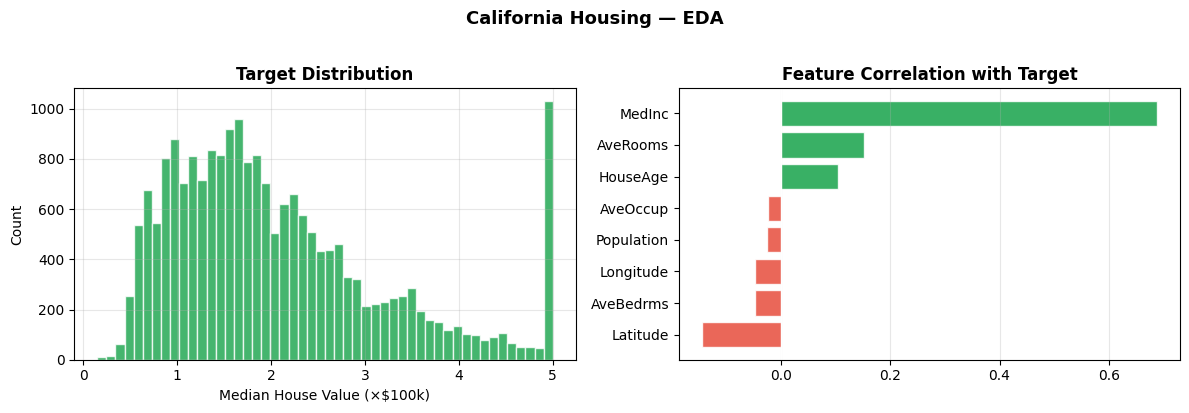

In [3]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y, bins=50, color='#16a34a', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Median House Value (×$100k)')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Feature correlations with target
corr = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values()
colors = ['#e74c3c' if v < 0 else '#16a34a' for v in corr]
bars = axes[1].barh(corr.index, corr.values, color=colors, alpha=0.85, edgecolor='white')
axes[1].set_title('Feature Correlation with Target', fontweight='bold')
axes[1].axvline(0, color='white', linewidth=0.8)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('California Housing — EDA', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.25)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

rt = DecisionTreeRegressor(criterion='squared_error', max_depth=5, random_state=42)
rt.fit(X_train, y_train)

y_pred = rt.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"\nDecisionTreeRegressor (max_depth=5)")
print(f"R² Score : {r2:.4f}")
print(f"Tree depth     : {rt.get_depth()}")
print(f"Leaf nodes     : {rt.get_n_leaves()}")

Train: (15480, 8)  |  Test: (5160, 8)

DecisionTreeRegressor (max_depth=5)
R² Score : 0.6019
Tree depth     : 5
Leaf nodes     : 32


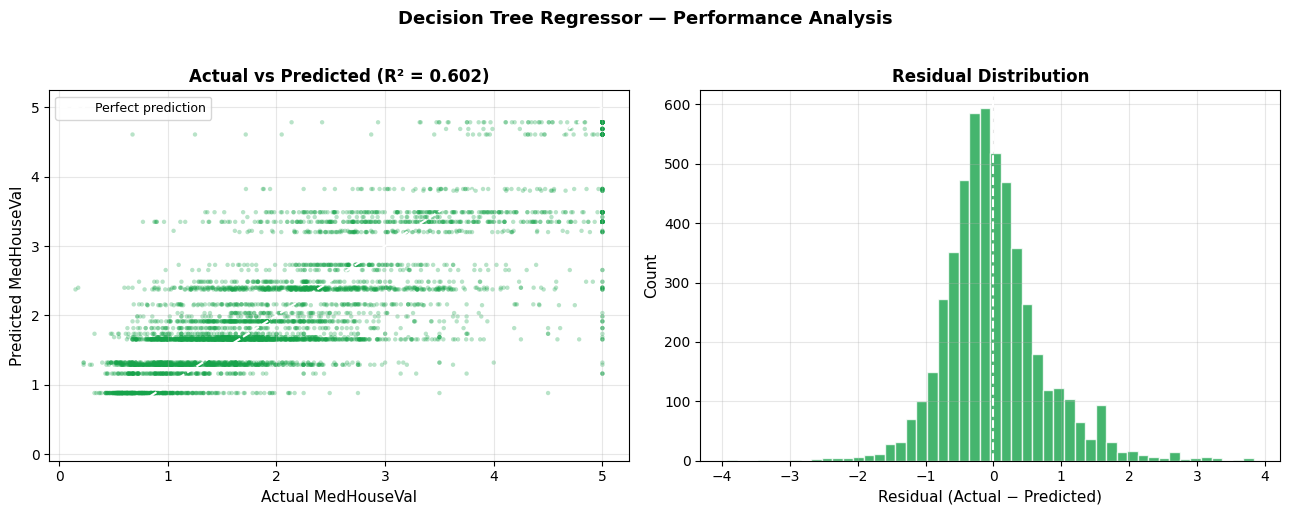

In [5]:
# Predicted vs actual scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='#16a34a', edgecolors='none')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'w--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual MedHouseVal', fontsize=11)
axes[0].set_ylabel('Predicted MedHouseVal', fontsize=11)
axes[0].set_title(f'Actual vs Predicted (R² = {r2:.3f})', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Residual distribution
residuals = y_test - y_pred
axes[1].hist(residuals, bins=50, color='#16a34a', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='white', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Residual (Actual − Predicted)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Decision Tree Regressor — Performance Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<a id='tuning'></a>
<div style="border-bottom: 2px solid #16a34a; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #16a34a; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 9</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">⚙️ RandomizedSearchCV — Hyperparameter Tuning</h2>
</div>

Decision Trees have several key hyperparameters. Rather than exhaustively testing all combinations (GridSearchCV), **RandomizedSearchCV** samples a fixed number of random combinations — much faster for large parameter spaces while still finding good configurations.

<div style="background: #060e06; border: 1px solid #1a4a1a; border-radius: 10px; padding: 16px 22px; margin: 14px 0; font-size: 13px;"><div style="display: grid; grid-template-columns: 1fr 1fr; gap: 16px;">
  <div><div style="color: #16a34a; font-weight: 700; margin-bottom: 6px;">Key Parameters</div>
    <div style="color: #bbf7d0; line-height: 1.8;"><code>max_depth</code> — limits tree depth (main overfitting control)<br/><code>min_samples_split</code> — minimum samples to attempt a split<br/><code>min_samples_leaf</code> — minimum samples in a leaf node<br/><code>max_features</code> — features considered per split<br/><code>criterion</code> — impurity measure<br/><code>splitter</code> — best vs random feature search</div>
  </div>
  <div><div style="color: #16a34a; font-weight: 700; margin-bottom: 6px;">RandomizedSearch vs GridSearch</div>
    <div style="color: #bbf7d0; line-height: 1.8;">GridSearchCV tests <strong style='color:#fff;'>every</strong> combination → O(n) where n = grid size.<br/>RandomizedSearchCV tests <strong style='color:#fff;'>n_iter</strong> random samples → same budget regardless of grid size.<br/>For large spaces, Randomized often finds equally good results 10-100× faster.</div>
  </div>
</div></div>

In [6]:
param_grid = {
    'criterion':        ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'splitter':         ['best', 'random'],
    'max_depth':        [None, 3, 5, 10, 15, 20, 25, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 4, 8, 10],
    'max_features':     [None, 'sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
for k, v in random_search.best_params_.items():
    print(f"  {k:<22}: {v}")
print(f"\nBest CV R² Score : {random_search.best_score_:.4f}")

Best Parameters:
  splitter              : random
  min_samples_split     : 20
  min_samples_leaf      : 10
  max_features          : None
  max_depth             : None
  criterion             : poisson

Best CV R² Score : 0.6853


In [7]:
best_rt = random_search.best_estimator_
y_pred_best = best_rt.predict(X_test)
r2_best = r2_score(y_test, y_pred_best)

print(f"Baseline (max_depth=5) R²  : {r2:.4f}")
print(f"Tuned model         R²  : {r2_best:.4f}")
print(f"Improvement              : +{r2_best - r2:.4f}")
print(f"\nTuned tree depth    : {best_rt.get_depth()}")
print(f"Tuned leaf nodes    : {best_rt.get_n_leaves()}")

Baseline (max_depth=5) R²  : 0.6019
Tuned model         R²  : 0.6816
Improvement              : +0.0797

Tuned tree depth    : 27
Tuned leaf nodes    : 1027


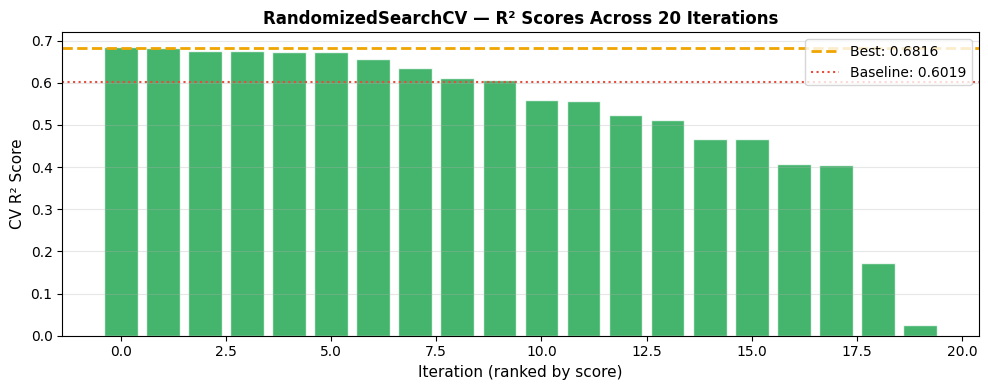

In [8]:
# CV scores across all 20 iterations
results_df = pd.DataFrame(random_search.cv_results_)
results_df = results_df.sort_values('rank_test_score').head(10)

fig, ax = plt.subplots(figsize=(10, 4))
all_scores = random_search.cv_results_['mean_test_score']
ax.bar(range(len(all_scores)), sorted(all_scores, reverse=True),
       color='#16a34a', alpha=0.8, edgecolor='white')
ax.axhline(r2_best, color='#f0a500', linewidth=2, linestyle='--', label=f'Best: {r2_best:.4f}')
ax.axhline(r2, color='#e74c3c', linewidth=1.5, linestyle=':', label=f'Baseline: {r2:.4f}')
ax.set_xlabel('Iteration (ranked by score)', fontsize=11)
ax.set_ylabel('CV R² Score', fontsize=11)
ax.set_title('RandomizedSearchCV — R² Scores Across 20 Iterations', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<a id='importance'></a>
<div style="border-bottom: 2px solid #16a34a; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #16a34a; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 10</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">📊 Feature Importance</h2>
</div>

A Decision Tree naturally ranks features by their **total impurity reduction** across all splits where that feature was used, weighted by the number of samples affected. This gives us a free measure of feature importance — a major advantage over algorithms like KNN or SVM.

<div style="background: #060e06; border: 1px solid #1a4a1a; border-radius: 8px; padding: 14px 20px; margin: 14px 0; font-size: 13px; color: #bbf7d0;">
  <strong style="color: #16a34a;">⚠️ Caveat:</strong> Single-tree feature importance is unstable — a different random seed or small data change can alter rankings significantly. For reliable importance, use <strong style='color:#d1fae5;'>Random Forest's</strong> averaged importance across hundreds of trees.
</div>

In [9]:
importances = rt.feature_importances_
feature_names = X.columns.tolist()

# Sort by importance
sorted_idx = np.argsort(importances)[::-1]
sorted_names = [feature_names[i] for i in sorted_idx]
sorted_imp   = importances[sorted_idx]

print("Feature Importances (baseline tree, max_depth=5):")
print("-" * 40)
for name, imp in zip(sorted_names, sorted_imp):
    bar = '█' * int(imp * 50)
    print(f"{name:<15} {bar} {imp:.4f}")

Feature Importances (baseline tree, max_depth=5):
----------------------------------------
MedInc          ██████████████████████████████████████ 0.7758
AveOccup        ██████ 0.1382
HouseAge        █ 0.0380
AveRooms        █ 0.0241
Latitude         0.0194
Population       0.0036
AveBedrms        0.0009
Longitude        0.0000


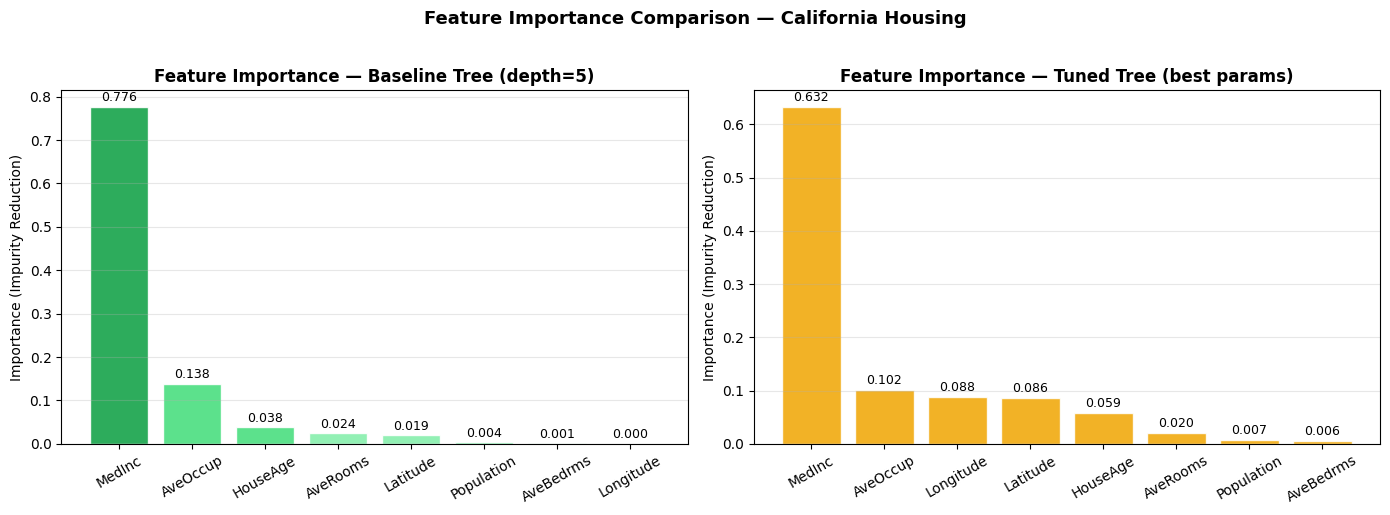

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline tree
colors_imp = ['#16a34a' if i == 0 else '#4ade80' if i < 3 else '#86efac' for i in range(len(sorted_names))]
bars = axes[0].bar(sorted_names, sorted_imp, color=colors_imp, alpha=0.9, edgecolor='white')
axes[0].bar_label(bars, fmt='%.3f', fontsize=9, padding=2)
axes[0].set_title('Feature Importance — Baseline Tree (depth=5)', fontweight='bold')
axes[0].set_ylabel('Importance (Impurity Reduction)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

# Tuned tree
imp_tuned = best_rt.feature_importances_
sorted_idx2   = np.argsort(imp_tuned)[::-1]
sorted_names2 = [feature_names[i] for i in sorted_idx2]
sorted_imp2   = imp_tuned[sorted_idx2]
bars2 = axes[1].bar(sorted_names2, sorted_imp2, color='#f0a500', alpha=0.85, edgecolor='white')
axes[1].bar_label(bars2, fmt='%.3f', fontsize=9, padding=2)
axes[1].set_title('Feature Importance — Tuned Tree (best params)', fontweight='bold')
axes[1].set_ylabel('Importance (Impurity Reduction)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Feature Importance Comparison — California Housing', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<div style="background: #060e06; border-left: 4px solid #16a34a; border-radius: 0 8px 8px 0; padding: 12px 18px; margin: 12px 0; font-size: 14px; color: #bbf7d0;">
  <strong style="color: #d1fae5;">💡 Key insight:</strong> <code>MedInc</code> (median income) dominates with ~77% importance in the baseline tree — median house value is very strongly driven by neighbourhood income. <code>AveOccup</code> (average occupancy) is a distant second at ~14%. <code>Longitude</code> gets 0% because the tree found no useful split on it within 5 levels.
</div>

<a id='classification'></a>
<div style="border-bottom: 2px solid #16a34a; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #16a34a; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 11</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🌸 Decision Tree Classification — Iris Dataset</h2>
</div>

For classification, the CART algorithm uses Gini impurity (default) or entropy instead of MSE. The leaf prediction is the **majority class** among training samples at that leaf. We use the Iris dataset — a clean 3-class benchmark where a decision tree can achieve near-perfect accuracy.

In [11]:
iris = load_iris()
X_iris  = iris.data
y_iris  = iris.target
feature_names = iris.feature_names
class_names   = iris.target_names.tolist()

print(f"Shape  : {X_iris.shape}")
print(f"Classes: {class_names}")
print(f"Samples per class: {np.bincount(y_iris)}")

Shape  : (150, 4)
Classes: ['setosa', 'versicolor', 'virginica']
Samples per class: [50 50 50]


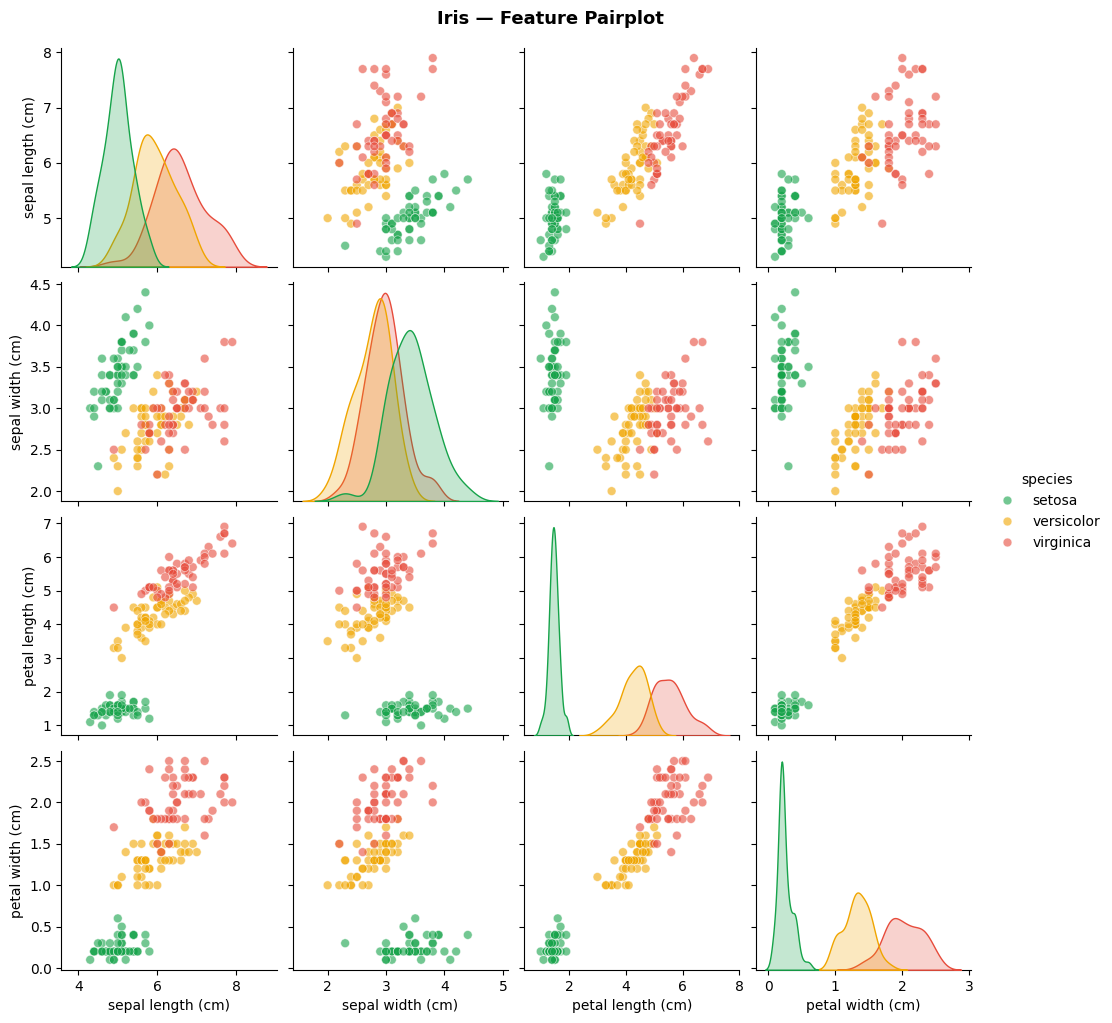

In [12]:
# Pairplot for EDA
iris_df = pd.DataFrame(X_iris, columns=feature_names)
iris_df['species'] = [class_names[i] for i in y_iris]

g = sns.pairplot(iris_df, hue='species',
                 palette={'setosa': '#16a34a', 'versicolor': '#f0a500', 'virginica': '#e74c3c'},
                 diag_kind='kde', plot_kws={'alpha': 0.6, 's': 40})
g.fig.suptitle('Iris — Feature Pairplot', y=1.02, fontsize=13, fontweight='bold')
plt.show()

In [13]:
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_iris, y_train_iris)

y_pred_iris = clf.predict(X_test_iris)
acc = accuracy_score(y_test_iris, y_pred_iris)

print(f"Accuracy : {acc:.4f}")
print(f"Depth    : {clf.get_depth()}")
print(f"Leaves   : {clf.get_n_leaves()}\n")
print(classification_report(y_test_iris, y_pred_iris, target_names=class_names))

Accuracy : 0.9333
Depth    : 5
Leaves   : 8

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



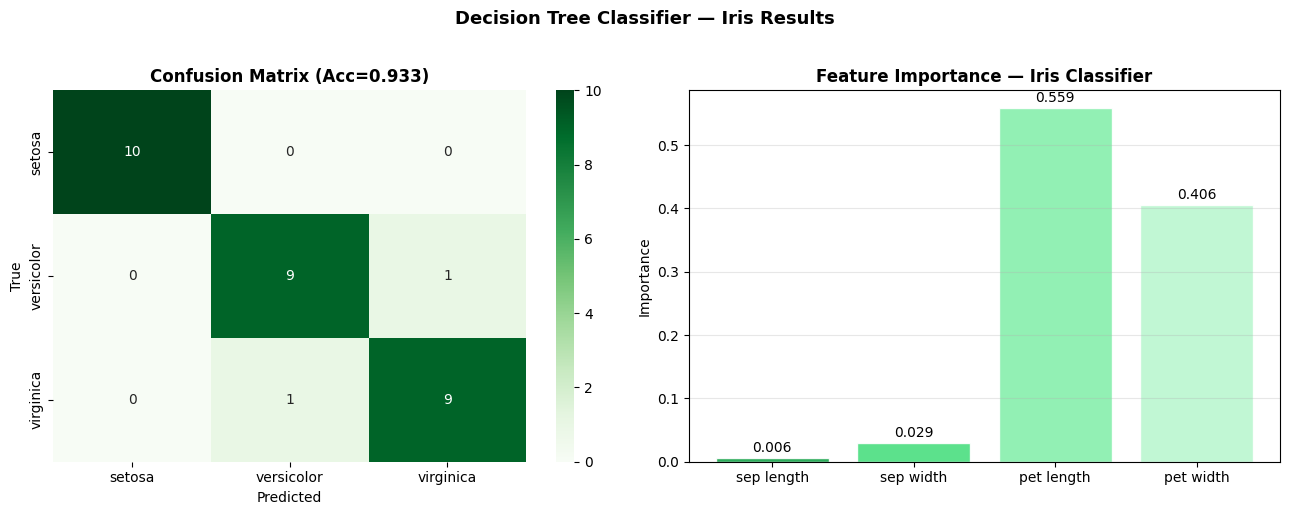

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test_iris, y_pred_iris)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title(f'Confusion Matrix (Acc={acc:.3f})', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Feature importance for classifier
imp_clf = clf.feature_importances_
short_names = [n.replace(' (cm)', '').replace('sepal', 'sep').replace('petal', 'pet') for n in feature_names]
bars = axes[1].bar(short_names, imp_clf, color=['#16a34a', '#4ade80', '#86efac', '#bbf7d0'],
                   alpha=0.9, edgecolor='white')
axes[1].bar_label(bars, fmt='%.3f', fontsize=10, padding=2)
axes[1].set_title('Feature Importance — Iris Classifier', fontweight='bold')
axes[1].set_ylabel('Importance')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Decision Tree Classifier — Iris Results', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<a id='viz'></a>
<div style="border-bottom: 2px solid #16a34a; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #16a34a; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 12</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🌳 Tree Visualisation &amp; Prediction Path</h2>
</div>

sklearn's `plot_tree()` renders the full tree structure — each node shows the split rule, Gini impurity, sample count, and class distribution. Nodes are colour-coded by majority class and become darker as purity increases.

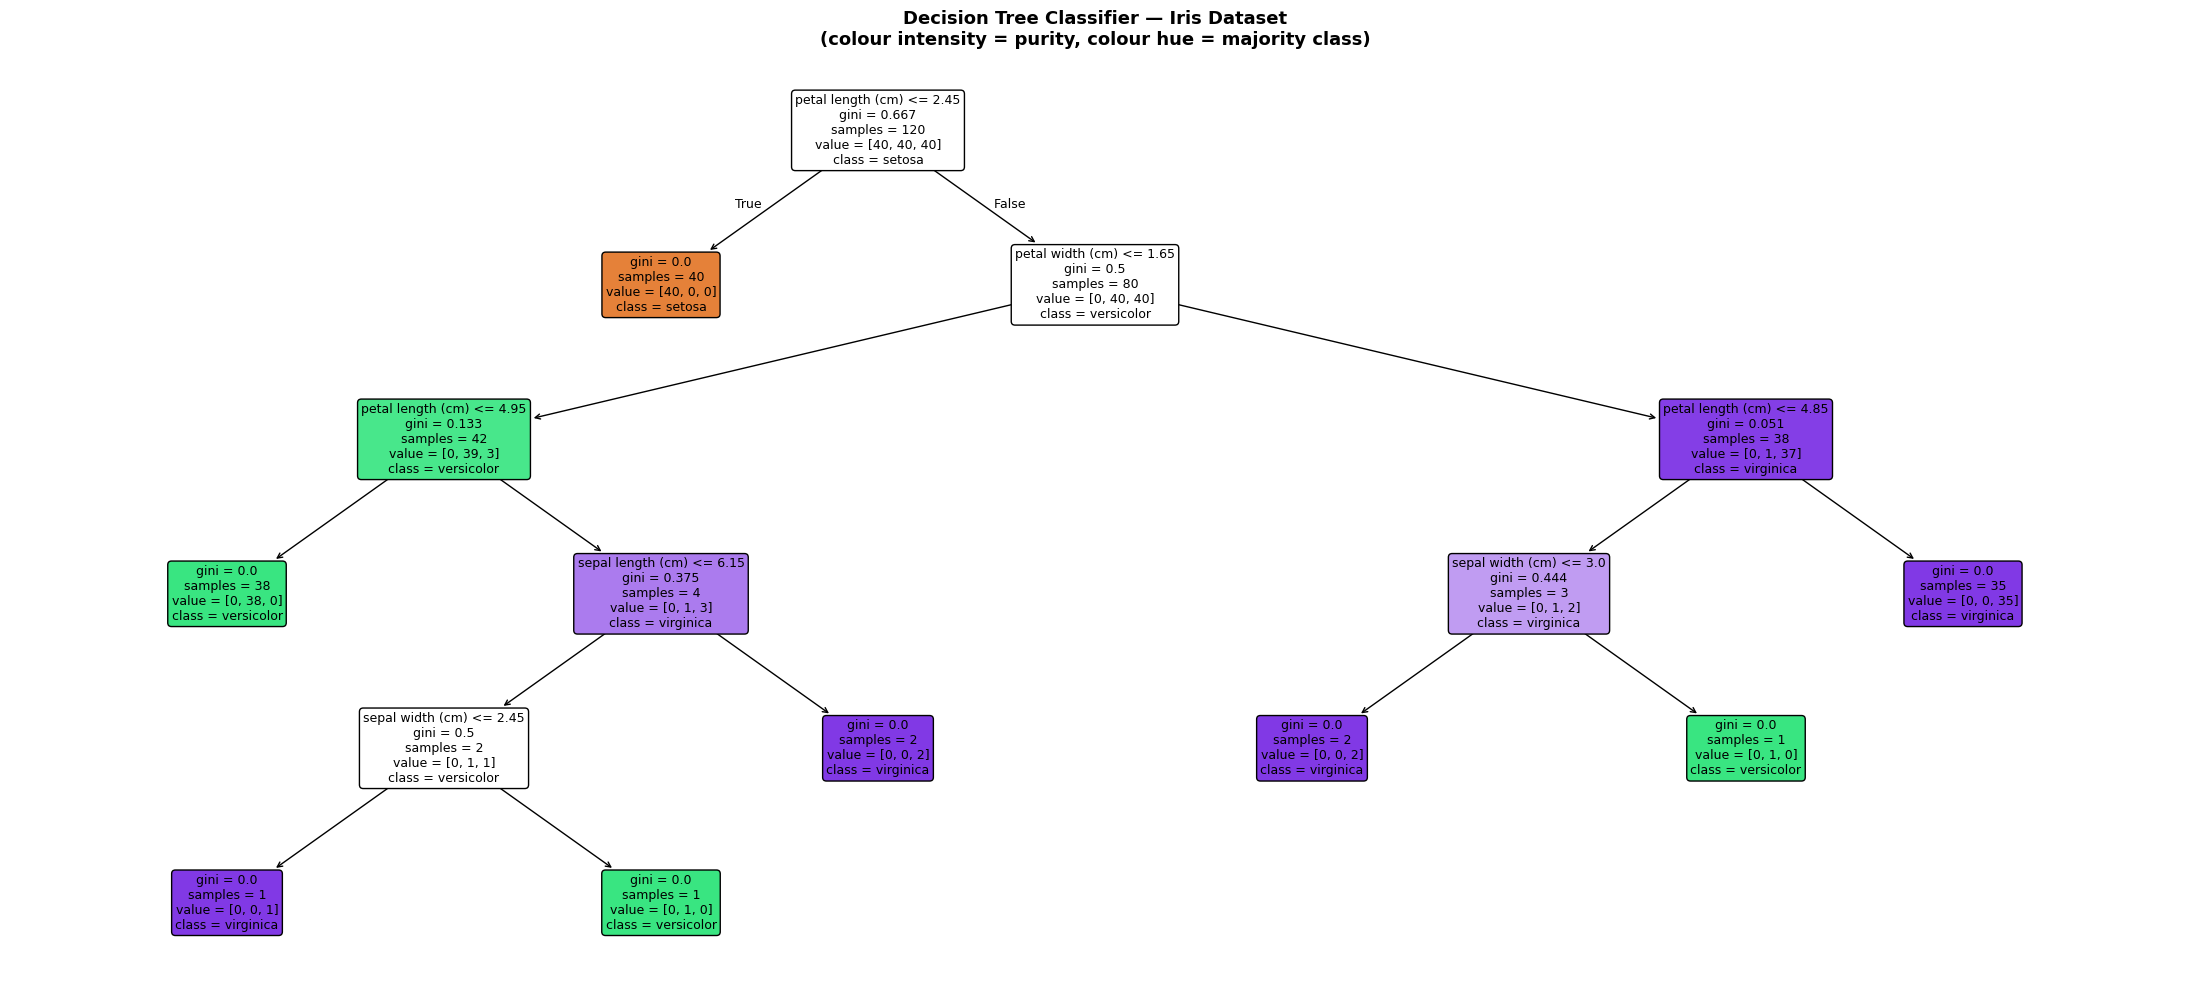

In [15]:
# Full tree visualisation — sklearn's built-in (no external dependency)
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    clf,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    impurity=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Decision Tree Classifier — Iris Dataset\n(colour intensity = purity, colour hue = majority class)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Text representation — easier to read for deep trees
print(export_text(clf, feature_names=feature_names))

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.65
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- sepal length (cm) <= 6.15
|   |   |   |   |--- sepal width (cm) <= 2.45
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- sepal width (cm) >  2.45
|   |   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  6.15
|   |   |   |   |--- class: 2
|   |--- petal width (cm) >  1.65
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal width (cm) <= 3.00
|   |   |   |   |--- class: 2
|   |   |   |--- sepal width (cm) >  3.00
|   |   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



In [17]:
# Predict a single sample and trace its path through the tree
sample_idx  = np.random.randint(len(X_iris))
sample      = X_iris[sample_idx]
true_class  = class_names[y_iris[sample_idx]]
pred_class  = class_names[clf.predict([sample])[0]]
pred_proba  = clf.predict_proba([sample])[0]

print(f"Sample features:")
for name, val in zip(feature_names, sample):
    print(f"  {name:<25}: {val:.2f}")
print(f"\nActual class    : {true_class}")
print(f"Predicted class : {pred_class}")
print(f"\nClass probabilities:")
for cls, p in zip(class_names, pred_proba):
    bar = '█' * int(p * 30)
    print(f"  {cls:<15} {bar} {p:.4f}")

Sample features:
  sepal length (cm)        : 7.10
  sepal width (cm)         : 3.00
  petal length (cm)        : 5.90
  petal width (cm)         : 2.10

Actual class    : virginica
Predicted class : virginica

Class probabilities:
  setosa           0.0000
  versicolor       0.0000
  virginica       ██████████████████████████████ 1.0000


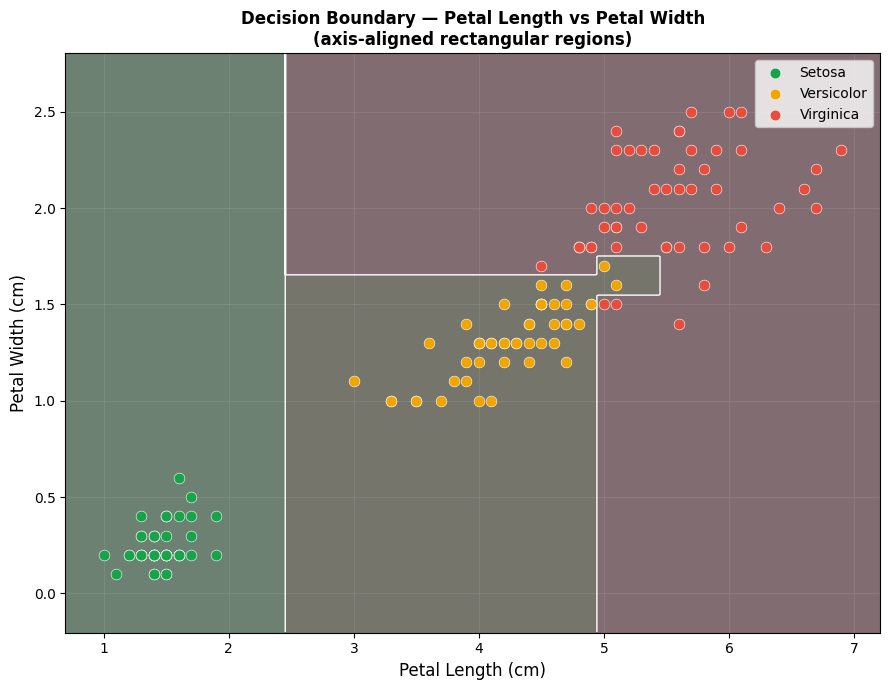

In [18]:
# Decision boundary — petal length vs petal width (most informative pair)
petal_l_idx = 2  # petal length
petal_w_idx = 3  # petal width

X_2feat = X_iris[:, [petal_l_idx, petal_w_idx]]
clf_2feat = DecisionTreeClassifier(random_state=42)
clf_2feat.fit(X_2feat, y_iris)

x_min, x_max = X_2feat[:, 0].min() - 0.3, X_2feat[:, 0].max() + 0.3
y_min, y_max = X_2feat[:, 1].min() - 0.3, X_2feat[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
Z = clf_2feat.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

from matplotlib.colors import ListedColormap
cmap_bg  = ListedColormap(['#0a2e14', '#1a1a0a', '#2e0a14'])
cmap_pts = ListedColormap(['#16a34a', '#f0a500', '#e74c3c'])

fig, ax = plt.subplots(figsize=(9, 7))
ax.pcolormesh(xx, yy, Z, cmap=cmap_bg, alpha=0.6, shading='auto')
ax.contour(xx, yy, Z, colors='white', linewidths=1.0, levels=[0.5, 1.5])

for cls, color, label in [(0, '#16a34a', 'Setosa'), (1, '#f0a500', 'Versicolor'), (2, '#e74c3c', 'Virginica')]:
    mask = y_iris == cls
    ax.scatter(X_2feat[mask, 0], X_2feat[mask, 1], c=color, s=60,
               edgecolors='white', linewidth=0.4, label=label, zorder=5)

ax.set_xlabel('Petal Length (cm)', fontsize=12)
ax.set_ylabel('Petal Width (cm)', fontsize=12)
ax.set_title('Decision Boundary — Petal Length vs Petal Width\n(axis-aligned rectangular regions)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

<div style="background: #060e06; border-left: 4px solid #16a34a; border-radius: 0 8px 8px 0; padding: 12px 18px; margin: 12px 0; font-size: 14px; color: #bbf7d0;">
  <strong style="color: #d1fae5;">✅ Decision boundary insight:</strong> The white lines show the tree's axis-aligned rectangular splits. Setosa (green) is perfectly separated at the first split (<code>petal length ≤ 2.45</code>). The boundary between Versicolor and Virginica requires multiple horizontal and vertical cuts — these are the internal nodes at depth 2+.
</div>

<a id='3d'></a>
<div style="border-bottom: 2px solid #16a34a; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #16a34a; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 13</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🗻 3D Regression Surface</h2>
</div>

For regression, the decision boundary concept becomes a **prediction surface** — a 3D surface showing the predicted value as a function of two features. A Decision Tree's surface is always a **staircase** (piecewise constant), reflecting the flat predicted value within each leaf region.

In [19]:
housing = fetch_california_housing()
X_h = housing.data
y_h = housing.target
feature_names_h = housing.feature_names

feature_1 = 'MedInc'
feature_2 = 'AveOccup'
idx_1 = list(feature_names_h).index(feature_1)
idx_2 = list(feature_names_h).index(feature_2)

# Clip AveOccup outliers for cleaner surface
X_2d = X_h[:, [idx_1, idx_2]]
mask = X_2d[:, 1] < 10          # remove extreme occupancy outliers
X_2d_clean = X_2d[mask]
y_clean     = y_h[mask]

rt_3d = DecisionTreeRegressor(max_depth=5, random_state=42)
rt_3d.fit(X_2d_clean, y_clean)

print(f"3D tree R² on clean data : {r2_score(y_clean, rt_3d.predict(X_2d_clean)):.4f}")

3D tree R² on clean data : 0.5963


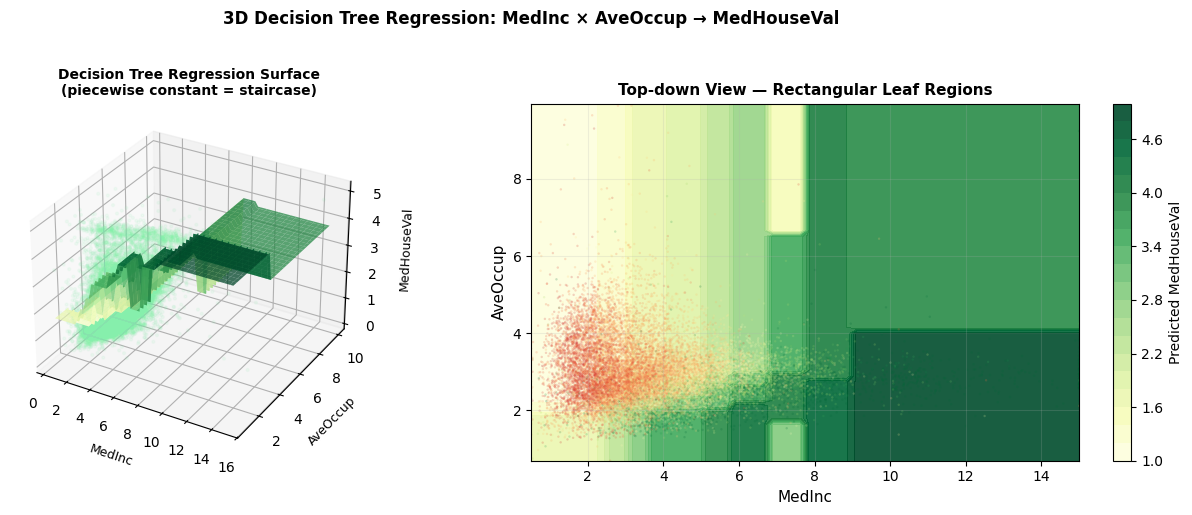

In [20]:
x1 = np.linspace(X_2d_clean[:, 0].min(), X_2d_clean[:, 0].max(), 60)
x2 = np.linspace(X_2d_clean[:, 1].min(), X_2d_clean[:, 1].max(), 60)
xx, yy = np.meshgrid(x1, x2)
zz = rt_3d.predict(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

fig = plt.figure(figsize=(14, 5))

# 3D surface
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_2d_clean[:, 0], X_2d_clean[:, 1], y_clean,
            alpha=0.08, s=4, color='#86efac')
surf = ax1.plot_surface(xx, yy, zz, alpha=0.75, cmap='YlGn')
ax1.set_xlabel(feature_1, fontsize=9, labelpad=5)
ax1.set_ylabel(feature_2, fontsize=9, labelpad=5)
ax1.set_zlabel('MedHouseVal', fontsize=9, labelpad=5)
ax1.set_title('Decision Tree Regression Surface\n(piecewise constant = staircase)', fontsize=10, fontweight='bold')

# Top-down view — shows rectangular regions
ax2 = fig.add_subplot(122)
c = ax2.contourf(xx, yy, zz, levels=20, cmap='YlGn', alpha=0.9)
plt.colorbar(c, ax=ax2, label='Predicted MedHouseVal')
ax2.scatter(X_2d_clean[:, 0], X_2d_clean[:, 1], c=y_clean,
            cmap='RdYlGn', s=3, alpha=0.2, edgecolors='none')
ax2.set_xlabel(feature_1, fontsize=11)
ax2.set_ylabel(feature_2, fontsize=11)
ax2.set_title('Top-down View — Rectangular Leaf Regions', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.2)

plt.suptitle(f'3D Decision Tree Regression: {feature_1} × {feature_2} → MedHouseVal',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<div style="background: linear-gradient(135deg, #0a1f0a 0%, #0d2e10 100%); border: 1px solid #1a4a1a; border-radius: 14px; padding: 36px 40px; margin-top: 32px;">
  <h2 style="color: #ffffff; font-size: 20px; font-weight: 700; margin: 0 0 8px 0;">📌 Summary &amp; Key Takeaways</h2>
  <p style="color: #86efac; font-size: 13px; margin: 0 0 20px 0;">Everything that matters about Decision Trees.</p>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; margin-bottom: 20px;">
    <div style="background: rgba(22,163,74,0.08); border: 1px solid #1a4a1a; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #16a34a; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🌿 Splitting Criterion</div>
      <div style="color: #bbf7d0; font-size: 12px; line-height: 1.7;">Gini (default, fast) and Entropy (info gain) give nearly identical results. Both measure node impurity — prefer the split that creates the purest children.</div>
    </div>
    <div style="background: rgba(22,163,74,0.08); border: 1px solid #1a4a1a; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #16a34a; font-weight: 700; font-size: 13px; margin-bottom: 6px;">📦 CART Algorithm</div>
      <div style="color: #bbf7d0; font-size: 12px; line-height: 1.7;">Greedy, top-down, binary splits. Locally optimal — doesn't guarantee the globally best tree. Works for both classification and regression.</div>
    </div>
    <div style="background: rgba(22,163,74,0.08); border: 1px solid #1a4a1a; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #16a34a; font-weight: 700; font-size: 13px; margin-bottom: 6px;">⚙️ Key Hyperparameters</div>
      <div style="color: #bbf7d0; font-size: 12px; line-height: 1.7;"><code>max_depth</code> is the primary overfitting control. <code>min_samples_leaf</code> prevents tiny leaves. Use <code>RandomizedSearchCV</code> to tune efficiently.</div>
    </div>
    <div style="background: rgba(22,163,74,0.08); border: 1px solid #1a4a1a; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #16a34a; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🗻 Piecewise Constant</div>
      <div style="color: #bbf7d0; font-size: 12px; line-height: 1.7;">Decision boundaries are always axis-aligned rectangles. The regression surface is a staircase. This makes trees interpretable but limited for smooth functions.</div>
    </div>
  </div>
  <a href='https://www.kaggle.com/code/ahmedfakhar123/ml-46-ensemble-learning-from-idea-to-code' style='text-decoration: none;'>
  <div style="padding-top: 14px; border-top: 1px solid #1a4a1a; color: #86efac; font-size: 12px;">
    Next up → <strong style='color:#16a34a;'>🤖 ML 46: Ensemble Learning — From Idea to Code</strong> 
  </div>
  </a>
</div>